# Segmentation Model Comparison

Reviewer comment being addressed:

> Do alternative automated segmentation strategies exist for this type of image and sample? ... it's difficult for the reader to contextualise the achievement without a comparison.

This notebook trains/evaluates **five candidate segmentation methods** on the *exact* train/val/test split used for the
published model (`models/data_split.json`), so all numbers are directly comparable to `results/analysis_results/table1_overall_performance.csv`.

| # | Method | Category | Pretrained? |
|---|--------|----------|-------------|
| 1 | **U-Net (ResNet34 encoder)** | current published model | ImageNet-pretrained encoder |
| 2 | **U-Net (ResNet34 encoder, from scratch)** | deep learning | No pretrained weights |
| 3 | **U-Net++ (ResNet34 encoder)** | deep learning, nested skip connections | ImageNet-pretrained encoder |
| 4 | **DeepLabV3+ (ResNet34 encoder)** | deep learning, atrous spatial pyramid pooling | ImageNet-pretrained encoder |
| 5 | **Random Forest pixel classifier** | classical ML, hand-crafted Mueller-matrix features | No pretrained weights, no deep learning |

Methods 2-4 use [`segmentation_models_pytorch`](https://github.com/qubvel-org/segmentation_models.pytorch) for well-tested,
standard implementations rather than hand-rolled architectures. Method 5 is a fully classical baseline built from the raw
polarimetric feature maps already present in the data (`M11`, depolarization, diattenuation, orientation, linear retardance)
so that the comparison contextualises the deep models against a "reasonable automated effort" that uses no learned
representations at all.

All models are evaluated with the same metric suite used for the published model: per-class Dice, IoU, Precision, Recall,
F1, Specificity, plus pixel accuracy and mean tissue Dice, computed at **native image resolution** (predictions are
upsampled back from 512x512, exactly like `m11_unet_test_sample_analysis.ipynb`).

**Run this notebook with the project's Python 3.10 / CUDA environment** (the one used by `notebooks/m11_unet/*`), not the
`.venv` in the repo root -- the repo `.venv` is CPU-only and is used for the annotator GUI packaging, not training.


In [1]:
import json
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp

warnings.filterwarnings('ignore')

print(f"PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\user_picm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.5.1+cu121 | CUDA available: True
GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU


## 1. Configuration

Same data split, input size, and training recipe as `notebooks/m11_unet/m11_unet_training.ipynb`, so the comparison is apples-to-apples.

In [2]:
class Config:
    # === PATHS (match the published model's notebooks) ===
    DATA_SPLIT_PATH = Path("../../models/data_split.json")
    REFERENCE_MODEL_PATH = Path("../../models/best_model.pth")
    OUTPUT_DIR = Path("../../models/comparison")
    RESULTS_DIR = Path("../../results/model_comparison")

    # === MODEL / INPUT ===
    ENCODER_NAME = 'resnet34'
    INPUT_SIZE = (512, 512)
    NUM_CLASSES = 4
    CLASS_NAMES = ['Background', 'Tissue', 'OS', 'Vaginal']

    # === TRAINING (mirrors the published training recipe) ===
    BATCH_SIZE = 8
    NUM_EPOCHS = 50          # set to e.g. 3 for a quick smoke test of the whole notebook
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 15
    INTENSITY_JITTER = 0.15
    NUM_WORKERS = 0

    RANDOM_SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(Config.RANDOM_SEED)
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
Config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {Config.DEVICE}")


Device: cuda


## 2. Data Loading

Loads the same NPZ fields used by the published model (`nM11s`/`M11s`, `tissue_mask`, `os_mask`, `vaginal_mask`), plus the extra polarimetric maps (`Mdepols`, `Mdiattenuations`, `Morientations`, `linrs`) needed for the Random Forest baseline's hand-crafted features.

In [3]:
def _robust_normalize(arr: np.ndarray, lo_pct=1, hi_pct=99) -> np.ndarray:
    """Clip to [lo_pct, hi_pct] percentiles then min-max scale to [0,1]. Handles NaN/Inf outliers
    that occur in the derived Mueller-matrix maps (e.g. Mdepols, Mdiattenuations) at invalid pixels."""
    arr = np.nan_to_num(arr.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    lo, hi = np.percentile(arr, [lo_pct, hi_pct])
    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)
    arr = np.clip(arr, lo, hi)
    return ((arr - lo) / (hi - lo)).astype(np.float32)


def load_sample(npz_path: Path) -> Optional[Dict[str, np.ndarray]]:
    """Load M11, auxiliary polarimetric maps, and the combined 4-class mask at native resolution."""
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            m11 = None
            if 'nM11s' in data:
                m11 = np.array(data['nM11s'], dtype=np.float32)
            elif 'M11s' in data:
                raw = np.array(data['M11s'], dtype=np.float32)
                m11 = (raw - raw.min()) / (raw.max() - raw.min() + 1e-6)
            if m11 is None or m11.ndim != 2:
                return None
            m11 = np.nan_to_num(m11, nan=0.0, posinf=0.0, neginf=0.0)

            tissue_mask = None
            for key in ['tissue_mask', 'annotation_mask']:
                if key in data and data[key].size > 0:
                    tissue_mask = np.array(data[key]) > 0
                    break
            if tissue_mask is None:
                return None

            os_mask = np.array(data['os_mask']) > 0 if ('os_mask' in data and data['os_mask'].size > 0) else None

            vag_mask = None
            for key in ['vaginal_mask', 'vaginal_wall', 'vaginal_wall_mask']:
                if key in data and data[key].size > 0:
                    vag_mask = np.array(data[key]) > 0
                    break

            combined_mask = np.zeros_like(tissue_mask, dtype=np.int64)
            combined_mask[tissue_mask] = 1
            if os_mask is not None:
                combined_mask[os_mask] = 2
            if vag_mask is not None:
                combined_mask[vag_mask] = 3

            aux = {}
            for out_key, npz_key in [('mdepol', 'Mdepols'), ('mdiatt', 'Mdiattenuations'),
                                      ('morient', 'Morientations'), ('linr', 'linrs')]:
                aux[out_key] = np.array(data[npz_key], dtype=np.float32) if npz_key in data else np.zeros_like(m11)

            return {'m11': m11, 'mask': combined_mask, **aux}
    except Exception as e:
        print(f"Error loading {npz_path}: {e}")
        return None


with open(Config.DATA_SPLIT_PATH, 'r') as f:
    data_split = json.load(f)

print(f"Train: {len(data_split['train'])} | Val: {len(data_split['val'])} | Test: {len(data_split['test'])}")


Train: 51 | Val: 11 | Test: 12


## 3. PyTorch Dataset (deep models)

Same preprocessing as the published model: per-image min-max M11, resize to 512x512, replicate to 3 channels, ImageNet normalization, geometric + intensity augmentation on train.

In [4]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)


def resize_2d(arr: np.ndarray, size: Tuple[int, int], is_mask: bool) -> np.ndarray:
    t = torch.from_numpy(arr).float().unsqueeze(0).unsqueeze(0)
    mode = 'nearest' if is_mask else 'bilinear'
    kwargs = {} if is_mask else {'align_corners': True}
    t = F.interpolate(t, size=size, mode=mode, **kwargs)
    return t.squeeze(0).squeeze(0).numpy()


class TissueDataset(Dataset):
    """M11-only dataset for the deep models (matches training notebook exactly)."""

    def __init__(self, sample_infos, input_size=Config.INPUT_SIZE, augment=False, intensity_jitter=0.0):
        self.input_size = input_size
        self.augment = augment
        self.intensity_jitter = intensity_jitter
        self.data = []
        for info in tqdm(sample_infos, desc="Loading samples"):
            res = load_sample(Path(info['path']))
            if res is not None:
                self.data.append((res['m11'], res['mask'], info['name']))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        m11, mask, _name = self.data[idx]
        m11 = resize_2d(m11, self.input_size, is_mask=False)
        mask = resize_2d(mask, self.input_size, is_mask=True)

        if self.augment:
            if np.random.rand() > 0.5:
                m11, mask = np.fliplr(m11), np.fliplr(mask)
            if np.random.rand() > 0.5:
                m11, mask = np.flipud(m11), np.flipud(mask)
            k = np.random.randint(0, 4)
            if k > 0:
                m11, mask = np.rot90(m11, k), np.rot90(mask, k)
            if self.intensity_jitter > 0:
                factor = 1.0 + np.random.uniform(-self.intensity_jitter, self.intensity_jitter)
                m11 = np.clip(m11 * factor, 0.0, 1.0)

        m11_rgb = np.ascontiguousarray(np.stack([m11, m11, m11], axis=0))
        m11_norm = (m11_rgb - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(m11_norm).float(), torch.from_numpy(np.ascontiguousarray(mask)).long()


train_ds = TissueDataset(data_split['train'], augment=True, intensity_jitter=Config.INTENSITY_JITTER)
val_ds = TissueDataset(data_split['val'], augment=False)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, num_workers=Config.NUM_WORKERS)

print(f"Train dataset: {len(train_ds)} | Val dataset: {len(val_ds)}")


Loading samples:   0%|          | 0/51 [00:00<?, ?it/s]

Loading samples:   4%|▍         | 2/51 [00:00<00:10,  4.67it/s]

Loading samples:   8%|▊         | 4/51 [00:00<00:06,  7.24it/s]

Loading samples:  10%|▉         | 5/51 [00:00<00:08,  5.24it/s]

Loading samples:  12%|█▏        | 6/51 [00:01<00:09,  4.83it/s]

...

Loading samples:  64%|██████▎   | 7/11 [00:01<00:00,  5.51it/s]

Loading samples:  82%|████████▏ | 9/11 [00:01<00:00,  6.90it/s]

Loading samples: 100%|██████████| 11/11 [00:01<00:00,  8.14it/s]

Loading samples: 100%|██████████| 11/11 [00:01<00:00,  6.66it/s]

Train dataset: 51 | Val dataset: 11


## 4. Metrics

Identical definitions to `m11_unet_test_sample_analysis.ipynb` (Dice, IoU, Precision, Recall, F1, Specificity per class; pixel accuracy; mean tissue Dice), computed at **native resolution** for every model.

In [5]:
def class_confusion(pred: np.ndarray, gt: np.ndarray, class_id: int):
    p = (pred == class_id)
    g = (gt == class_id)
    tp = np.logical_and(p, g).sum(dtype=np.int64)
    fp = np.logical_and(p, ~g).sum(dtype=np.int64)
    fn = np.logical_and(~p, g).sum(dtype=np.int64)
    tn = np.logical_and(~p, ~g).sum(dtype=np.int64)
    return tp, fp, fn, tn


def per_class_metrics(pred: np.ndarray, gt: np.ndarray, class_id: int) -> Dict[str, float]:
    tp, fp, fn, tn = class_confusion(pred, gt, class_id)
    union = tp + fp + fn
    dice = 1.0 if union == 0 else (2.0 * tp) / (2 * tp + fp + fn)
    iou = 1.0 if union == 0 else tp / union
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {'dice': dice, 'iou': iou, 'precision': precision, 'recall': recall,
            'f1': f1, 'specificity': specificity}


def evaluate_sample(pred: np.ndarray, gt: np.ndarray) -> Dict:
    per_class = {c: per_class_metrics(pred, gt, c) for c in range(Config.NUM_CLASSES)}
    pixel_acc = float((pred == gt).mean())
    tissue_dice = float(np.mean([per_class[c]['dice'] for c in range(1, Config.NUM_CLASSES)]))
    return {'per_class': per_class, 'pixel_accuracy': pixel_acc, 'mean_tissue_dice': tissue_dice}


def evaluate_model_on_split(predict_fn, split_samples, model_name: str) -> pd.DataFrame:
    """predict_fn(npz_path) -> (pred_mask_native_res, gt_mask_native_res)"""
    rows = []
    for info in tqdm(split_samples, desc=f"Evaluating {model_name}"):
        pred, gt = predict_fn(Path(info['path']))
        if pred is None:
            continue
        m = evaluate_sample(pred, gt)
        row = {'model': model_name, 'sample': info['name'],
               'pixel_accuracy': m['pixel_accuracy'], 'mean_tissue_dice': m['mean_tissue_dice']}
        for c, cname in enumerate(Config.CLASS_NAMES):
            for metric_name, val in m['per_class'][c].items():
                row[f'{cname}_{metric_name}'] = val
        rows.append(row)
    return pd.DataFrame(rows)


all_results = []  # list of per-sample DataFrames, one per model
print("Metric functions defined")


Metric functions defined


## 5. Shared Training Loop (deep models)

Cross-entropy + Dice loss, AMP, early stopping on validation loss -- same recipe as the published U-Net so training-procedure differences don't confound the architecture comparison.

In [6]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        pred_soft = F.softmax(pred, dim=1)
        target_onehot = F.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (pred_soft * target_onehot).sum(dims)
        cardinality = pred_soft.sum(dims) + target_onehot.sum(dims)
        dice_loss = 1.0 - ((2.0 * intersection + 1e-6) / (cardinality + 1e-6)).mean()
        return ce_loss + dice_loss


def pixel_accuracy(pred_logits, target):
    pred_class = torch.argmax(pred_logits, dim=1)
    return (pred_class == target).float().mean().item()


def train_model(model: nn.Module, name: str, train_loader, val_loader,
                 num_epochs=Config.NUM_EPOCHS, patience=Config.PATIENCE) -> pd.DataFrame:
    model = model.to(Config.DEVICE)
    criterion = CombinedLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
    scaler = GradScaler()

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = []
    ckpt_path = Config.OUTPUT_DIR / f'{name}.pth'

    for epoch in range(num_epochs):
        model.train()
        train_loss = train_acc = 0.0
        for img, mask in tqdm(train_loader, desc=f"[{name}] Epoch {epoch + 1}/{num_epochs}", leave=False):
            img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
            optimizer.zero_grad()
            with autocast():
                pred = model(img)
                if pred.shape[-2:] != mask.shape[-2:]:
                    pred = F.interpolate(pred, size=mask.shape[-2:], mode='bilinear', align_corners=True)
                loss = criterion(pred, mask)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            train_acc += pixel_accuracy(pred, mask)
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        model.eval()
        val_loss = val_acc = 0.0
        with torch.no_grad():
            for img, mask in val_loader:
                img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
                pred = model(img)
                if pred.shape[-2:] != mask.shape[-2:]:
                    pred = F.interpolate(pred, size=mask.shape[-2:], mode='bilinear', align_corners=True)
                val_loss += criterion(pred, mask).item()
                val_acc += pixel_accuracy(pred, mask)
        val_loss /= len(val_loader)
        val_acc /= len(val_loader)

        history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'train_acc': train_acc,
                         'val_loss': val_loss, 'val_acc': val_acc})
        print(f"[{name}] Epoch {epoch + 1:3d} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch + 1,
                        'val_loss': val_loss, 'val_acc': val_acc}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{name}] Early stopping at epoch {epoch + 1}")
                break

    model.load_state_dict(torch.load(ckpt_path, weights_only=False)['model_state_dict'])
    return model, pd.DataFrame(history)


@torch.no_grad()
def make_deep_predict_fn(model: nn.Module):
    """Wrap a trained deep model into predict_fn(npz_path) -> (pred_native_res, gt_native_res)."""
    model.eval()

    def predict_fn(npz_path: Path):
        sample = load_sample(npz_path)
        if sample is None:
            return None, None
        m11, gt = sample['m11'], sample['mask']
        x = resize_2d(m11, Config.INPUT_SIZE, is_mask=False)
        x_rgb = np.stack([x, x, x], axis=0)
        x_norm = (x_rgb - IMAGENET_MEAN) / IMAGENET_STD
        x_t = torch.from_numpy(x_norm).float().unsqueeze(0).to(Config.DEVICE)
        logits = model(x_t)
        pred = torch.argmax(logits, dim=1).float()
        pred = F.interpolate(pred.unsqueeze(1), size=gt.shape, mode='nearest').squeeze().long()
        return pred.cpu().numpy(), gt

    return predict_fn


print("Training utilities defined")


Training utilities defined


## 6. Candidate 1 (reference) -- Published U-Net (pretrained ResNet34 encoder)

Loads the already-trained `models/best_model.pth` -- no retraining, just re-run through the shared evaluation pipeline so it appears in the same comparison table as the new candidates.

In [7]:
class PublishedUNet(nn.Module):
    """Matches run_trained/model_utils.py / notebooks/m11_unet training architecture exactly."""

    def __init__(self, num_classes):
        super().__init__()
        import torchvision.models as tv_models
        # self.encoder must be kept as an attribute (even though enc1..enc5 hold the actual
        # forward-pass references) because the saved checkpoint's state_dict includes
        # "encoder.*" keys from the original training class -- see model_utils.py / training notebook.
        self.encoder = tv_models.resnet34(weights=None)
        enc_layers = list(self.encoder.children())
        self.enc1 = nn.Sequential(*enc_layers[:3])
        self.enc2 = nn.Sequential(*enc_layers[3:5])
        self.enc3 = enc_layers[5]
        self.enc4 = enc_layers[6]
        self.enc5 = enc_layers[7]
        self.dec4 = self._block(512 + 256, 256)
        self.dec3 = self._block(256 + 128, 128)
        self.dec2 = self._block(128 + 64, 64)
        self.dec1 = self._block(64 + 64, 32)
        self.final = nn.Conv2d(32, num_classes, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU())

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2); e4 = self.enc4(e3); e5 = self.enc5(e4)
        d4 = F.interpolate(e5, size=e4.shape[2:], mode='bilinear')
        d4 = self.dec4(torch.cat([d4, e4], 1))
        d3 = F.interpolate(d4, size=e3.shape[2:], mode='bilinear')
        d3 = self.dec3(torch.cat([d3, e3], 1))
        d2 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear')
        d2 = self.dec2(torch.cat([d2, e2], 1))
        d1 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear')
        d1 = self.dec1(torch.cat([d1, e1], 1))
        out = F.interpolate(d1, scale_factor=2, mode='bilinear')
        return self.final(out)


checkpoint = torch.load(Config.REFERENCE_MODEL_PATH, map_location=Config.DEVICE, weights_only=False)
reference_model = PublishedUNet(num_classes=Config.NUM_CLASSES).to(Config.DEVICE)
reference_model.load_state_dict(checkpoint['model_state_dict'])
reference_model.eval()

reference_predict_fn = make_deep_predict_fn(reference_model)
reference_results = evaluate_model_on_split(reference_predict_fn, data_split['test'], 'UNet_Pretrained_Published')
all_results.append(reference_results)
reference_results.describe()


Evaluating UNet_Pretrained_Published:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating UNet_Pretrained_Published:   8%|▊         | 1/12 [00:00<00:07,  1.55it/s]

Evaluating UNet_Pretrained_Published:  17%|█▋        | 2/12 [00:00<00:03,  2.64it/s]

Evaluating UNet_Pretrained_Published:  25%|██▌       | 3/12 [00:00<00:02,  3.77it/s]

Evaluating UNet_Pretrained_Published:  33%|███▎      | 4/12 [00:01<00:02,  3.18it/s]

...

Evaluating UNet_Pretrained_Published:  83%|████████▎ | 10/12 [00:03<00:00,  3.15it/s]

Evaluating UNet_Pretrained_Published:  92%|█████████▏| 11/12 [00:03<00:00,  3.81it/s]

Evaluating UNet_Pretrained_Published: 100%|██████████| 12/12 [00:03<00:00,  4.37it/s]

Evaluating UNet_Pretrained_Published: 100%|██████████| 12/12 [00:03<00:00,  3.54it/s]

,pixel_accuracy,mean_tissue_dice,Background_dice,Background_iou,Background_precision,Background_recall,Background_f1,Background_specificity,Tissue_dice,Tissue_iou,...,OS_precision,OS_recall,OS_f1,OS_specificity,Vaginal_dice,Vaginal_iou,Vaginal_precision,Vaginal_recall,Vaginal_f1,Vaginal_specificity
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.902190,0.811037,0.936417,0.889036,0.912633,0.969732,0.936417,0.972473,0.889637,0.803252,...,0.789722,0.903034,0.837862,0.973031,0.705611,0.622710,0.597851,0.657759,0.622278,0.968537
std,0.043138,0.134535,0.080149,0.124680,0.122460,0.025397,0.080149,0.019554,0.039127,0.063152,...,0.096574,0.128148,0.093446,0.016802,0.344337,0.322100,0.367411,0.416645,0.385196,0.026694
min,0.824869,0.489910,0.717077,0.558940,0.573592,0.908848,0.717077,0.944905,0.825266,0.702513,...,0.611599,0.564660,0.587193,0.923866,0.000000,0.000000,0.000000,0.000000,0.000000,0.915064
25%,0.875425,0.792144,0.951886,0.908523,0.921212,0.956634,0.951886,0.955237,0.854085,0.745363,...,0.719334,0.905163,0.807997,0.972185,0.747831,0.605994,0.505098,0.382366,0.435466,0.958382
50%,0.922742,0.866084,0.970952,0.943545,0.947864,0.973229,0.970952,0.972805,0.896323,0.812152,...,0.820588,0.953343,0.868779,0.975135,0.840968,0.726226,0.773255,0.885885,0.814664,0.971667
75%,0.931260,0.899386,0.976110,0.953336,0.982362,0.988701,0.976110,0.990731,0.920304,0.852435,...,0.856452,0.979558,0.904421,0.978602,0.894223,0.808699,0.834770,0.951757,0.886753,0.989076
max,0.948670,0.914519,0.984188,0.968868,0.995573,0.997692,0.984188,0.995325,0.940924,0.888438,...,0.921924,0.990189,0.915403,0.992849,1.000000,1.000000,0.893585,0.995975,0.913197,1.000000


## 7. Candidate 2 -- U-Net, ResNet34 encoder trained **from scratch** (no pretrained weights)

Isolates how much of the published model's performance comes from ImageNet transfer learning versus the architecture/training recipe itself.

In [8]:
unet_scratch = smp.Unet(encoder_name=Config.ENCODER_NAME, encoder_weights=None,
                         in_channels=3, classes=Config.NUM_CLASSES)
unet_scratch, unet_scratch_history = train_model(unet_scratch, 'UNet_NoPretrained', train_loader, val_loader)

unet_scratch_predict_fn = make_deep_predict_fn(unet_scratch)
unet_scratch_results = evaluate_model_on_split(unet_scratch_predict_fn, data_split['test'], 'UNet_NoPretrained')
all_results.append(unet_scratch_results)
unet_scratch_results.describe()


[UNet_NoPretrained] Epoch 1/50:   0%|          | 0/7 [00:00<?, ?it/s]

[UNet_NoPretrained] Epoch 1/50:  14%|█▍        | 1/7 [00:00<00:02,  2.62it/s]

[UNet_NoPretrained] Epoch 1/50:  29%|██▊       | 2/7 [00:00<00:01,  4.04it/s]

[UNet_NoPretrained] Epoch 1/50:  43%|████▎     | 3/7 [00:00<00:00,  4.96it/s]

[UNet_NoPretrained] Epoch 1/50:  57%|█████▋    | 4/7 [00:00<00:00,  5.55it/s]

...

Evaluating UNet_NoPretrained:  83%|████████▎ | 10/12 [00:02<00:00,  3.13it/s]

Evaluating UNet_NoPretrained:  92%|█████████▏| 11/12 [00:03<00:00,  3.74it/s]

Evaluating UNet_NoPretrained: 100%|██████████| 12/12 [00:03<00:00,  4.29it/s]

Evaluating UNet_NoPretrained: 100%|██████████| 12/12 [00:03<00:00,  3.79it/s]

,pixel_accuracy,mean_tissue_dice,Background_dice,Background_iou,Background_precision,Background_recall,Background_f1,Background_specificity,Tissue_dice,Tissue_iou,...,OS_precision,OS_recall,OS_f1,OS_specificity,Vaginal_dice,Vaginal_iou,Vaginal_precision,Vaginal_recall,Vaginal_f1,Vaginal_specificity
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.821823,0.628817,0.893690,0.819899,0.925071,0.869284,0.893690,0.983445,0.827320,0.710649,...,0.785301,0.634554,0.683449,0.979833,0.375683,0.279119,0.584885,0.303015,0.375683,0.983581
std,0.078280,0.169036,0.099718,0.146781,0.122842,0.098336,0.099718,0.020461,0.069762,0.094712,...,0.160451,0.235842,0.188262,0.015904,0.319363,0.267633,0.378059,0.290439,0.319363,0.014425
min,0.670726,0.403524,0.649716,0.481170,0.606630,0.699391,0.649716,0.937553,0.652411,0.484132,...,0.441255,0.322749,0.384822,0.946699,0.000000,0.000000,0.000000,0.000000,0.000000,0.955814
25%,0.754995,0.499138,0.874394,0.776844,0.914677,0.814628,0.874394,0.979605,0.816408,0.690082,...,0.675448,0.395977,0.548711,0.973269,0.137888,0.075924,0.414384,0.081711,0.137888,0.976719
50%,0.846977,0.577650,0.927818,0.865357,0.986466,0.868727,0.927818,0.991907,0.845721,0.732782,...,0.865970,0.708202,0.703059,0.986011,0.280308,0.163636,0.717385,0.180581,0.280308,0.990503
75%,0.880894,0.776997,0.956205,0.916086,0.996411,0.947847,0.956205,0.998244,0.867889,0.766624,...,0.889433,0.820356,0.842294,0.989784,0.684157,0.521574,0.883387,0.565720,0.684157,0.994250
max,0.915480,0.874139,0.984717,0.969894,0.998912,0.991376,0.984717,0.999179,0.897446,0.813971,...,0.951121,0.910602,0.895961,0.998162,0.832982,0.713769,0.924908,0.784789,0.832982,0.997513


In [9]:
unet_scratch_history.to_csv(Config.OUTPUT_DIR / 'UNet_NoPretrained_history.csv', index=False)
print("Saved UNet_NoPretrained_history.csv")

Saved UNet_NoPretrained_history.csv


## 8. Candidate 3 -- U-Net++ (pretrained ResNet34 encoder)

Nested/dense skip connections reduce the encoder-decoder semantic gap and are widely reported to help in low-data medical-imaging regimes (Zhou et al., 2018).

In [10]:
unet_pp = smp.UnetPlusPlus(encoder_name=Config.ENCODER_NAME, encoder_weights='imagenet',
                            in_channels=3, classes=Config.NUM_CLASSES)
unet_pp, unet_pp_history = train_model(unet_pp, 'UNetPlusPlus_Pretrained', train_loader, val_loader)

unet_pp_predict_fn = make_deep_predict_fn(unet_pp)
unet_pp_results = evaluate_model_on_split(unet_pp_predict_fn, data_split['test'], 'UNetPlusPlus_Pretrained')
all_results.append(unet_pp_results)
unet_pp_results.describe()


[UNetPlusPlus_Pretrained] Epoch 1/50:   0%|          | 0/7 [00:00<?, ?it/s]

[UNetPlusPlus_Pretrained] Epoch 1/50:  14%|█▍        | 1/7 [00:00<00:02,  2.27it/s]

[UNetPlusPlus_Pretrained] Epoch 1/50:  29%|██▊       | 2/7 [00:00<00:01,  2.96it/s]

[UNetPlusPlus_Pretrained] Epoch 1/50:  43%|████▎     | 3/7 [00:00<00:01,  3.30it/s]

[UNetPlusPlus_Pretrained] Epoch 1/50:  57%|█████▋    | 4/7 [00:01<00:00,  3.47it/s]

...

Evaluating UNetPlusPlus_Pretrained:  83%|████████▎ | 10/12 [00:02<00:00,  2.98it/s]

Evaluating UNetPlusPlus_Pretrained:  92%|█████████▏| 11/12 [00:03<00:00,  3.53it/s]

Evaluating UNetPlusPlus_Pretrained: 100%|██████████| 12/12 [00:03<00:00,  4.00it/s]

Evaluating UNetPlusPlus_Pretrained: 100%|██████████| 12/12 [00:03<00:00,  3.61it/s]

,pixel_accuracy,mean_tissue_dice,Background_dice,Background_iou,Background_precision,Background_recall,Background_f1,Background_specificity,Tissue_dice,Tissue_iou,...,OS_precision,OS_recall,OS_f1,OS_specificity,Vaginal_dice,Vaginal_iou,Vaginal_precision,Vaginal_recall,Vaginal_f1,Vaginal_specificity
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.908573,0.809605,0.949010,0.906813,0.954725,0.946293,0.949010,0.986594,0.903863,0.826075,...,0.841879,0.857087,0.844242,0.982982,0.680711,0.593458,0.618271,0.601645,0.597378,0.973297
std,0.043936,0.146120,0.051019,0.086454,0.069485,0.052365,0.051019,0.011566,0.032948,0.053971,...,0.108228,0.167585,0.131526,0.013695,0.344857,0.328497,0.387949,0.394403,0.379746,0.020816
min,0.807755,0.448063,0.840300,0.724584,0.754687,0.807438,0.840300,0.957269,0.834862,0.716535,...,0.575499,0.374669,0.453860,0.941324,0.000000,0.000000,0.000000,0.000000,0.000000,0.929585
25%,0.893160,0.780932,0.952525,0.909490,0.955170,0.932002,0.952525,0.982528,0.884605,0.793162,...,0.800473,0.847696,0.826212,0.983971,0.587859,0.417338,0.401569,0.268998,0.390212,0.962182
50%,0.927883,0.880281,0.970758,0.943182,0.982360,0.960161,0.970758,0.990605,0.912307,0.838761,...,0.881394,0.917933,0.876972,0.986323,0.851036,0.740699,0.846692,0.807484,0.801370,0.976851
75%,0.937825,0.908904,0.977854,0.956667,0.989674,0.986275,0.977854,0.993318,0.927697,0.865144,...,0.906075,0.956257,0.921756,0.988516,0.900728,0.819387,0.884236,0.890684,0.882311,0.986631
max,0.952465,0.924191,0.986578,0.973511,0.995019,0.992693,0.986578,0.997864,0.944471,0.894784,...,0.948505,0.970517,0.933488,0.995161,1.000000,1.000000,0.947020,0.933964,0.905083,1.000000


In [11]:
unet_pp_history.to_csv(Config.OUTPUT_DIR / 'UNetPlusPlus_Pretrained_history.csv', index=False)
print("Saved UNetPlusPlus_Pretrained_history.csv")

Saved UNetPlusPlus_Pretrained_history.csv


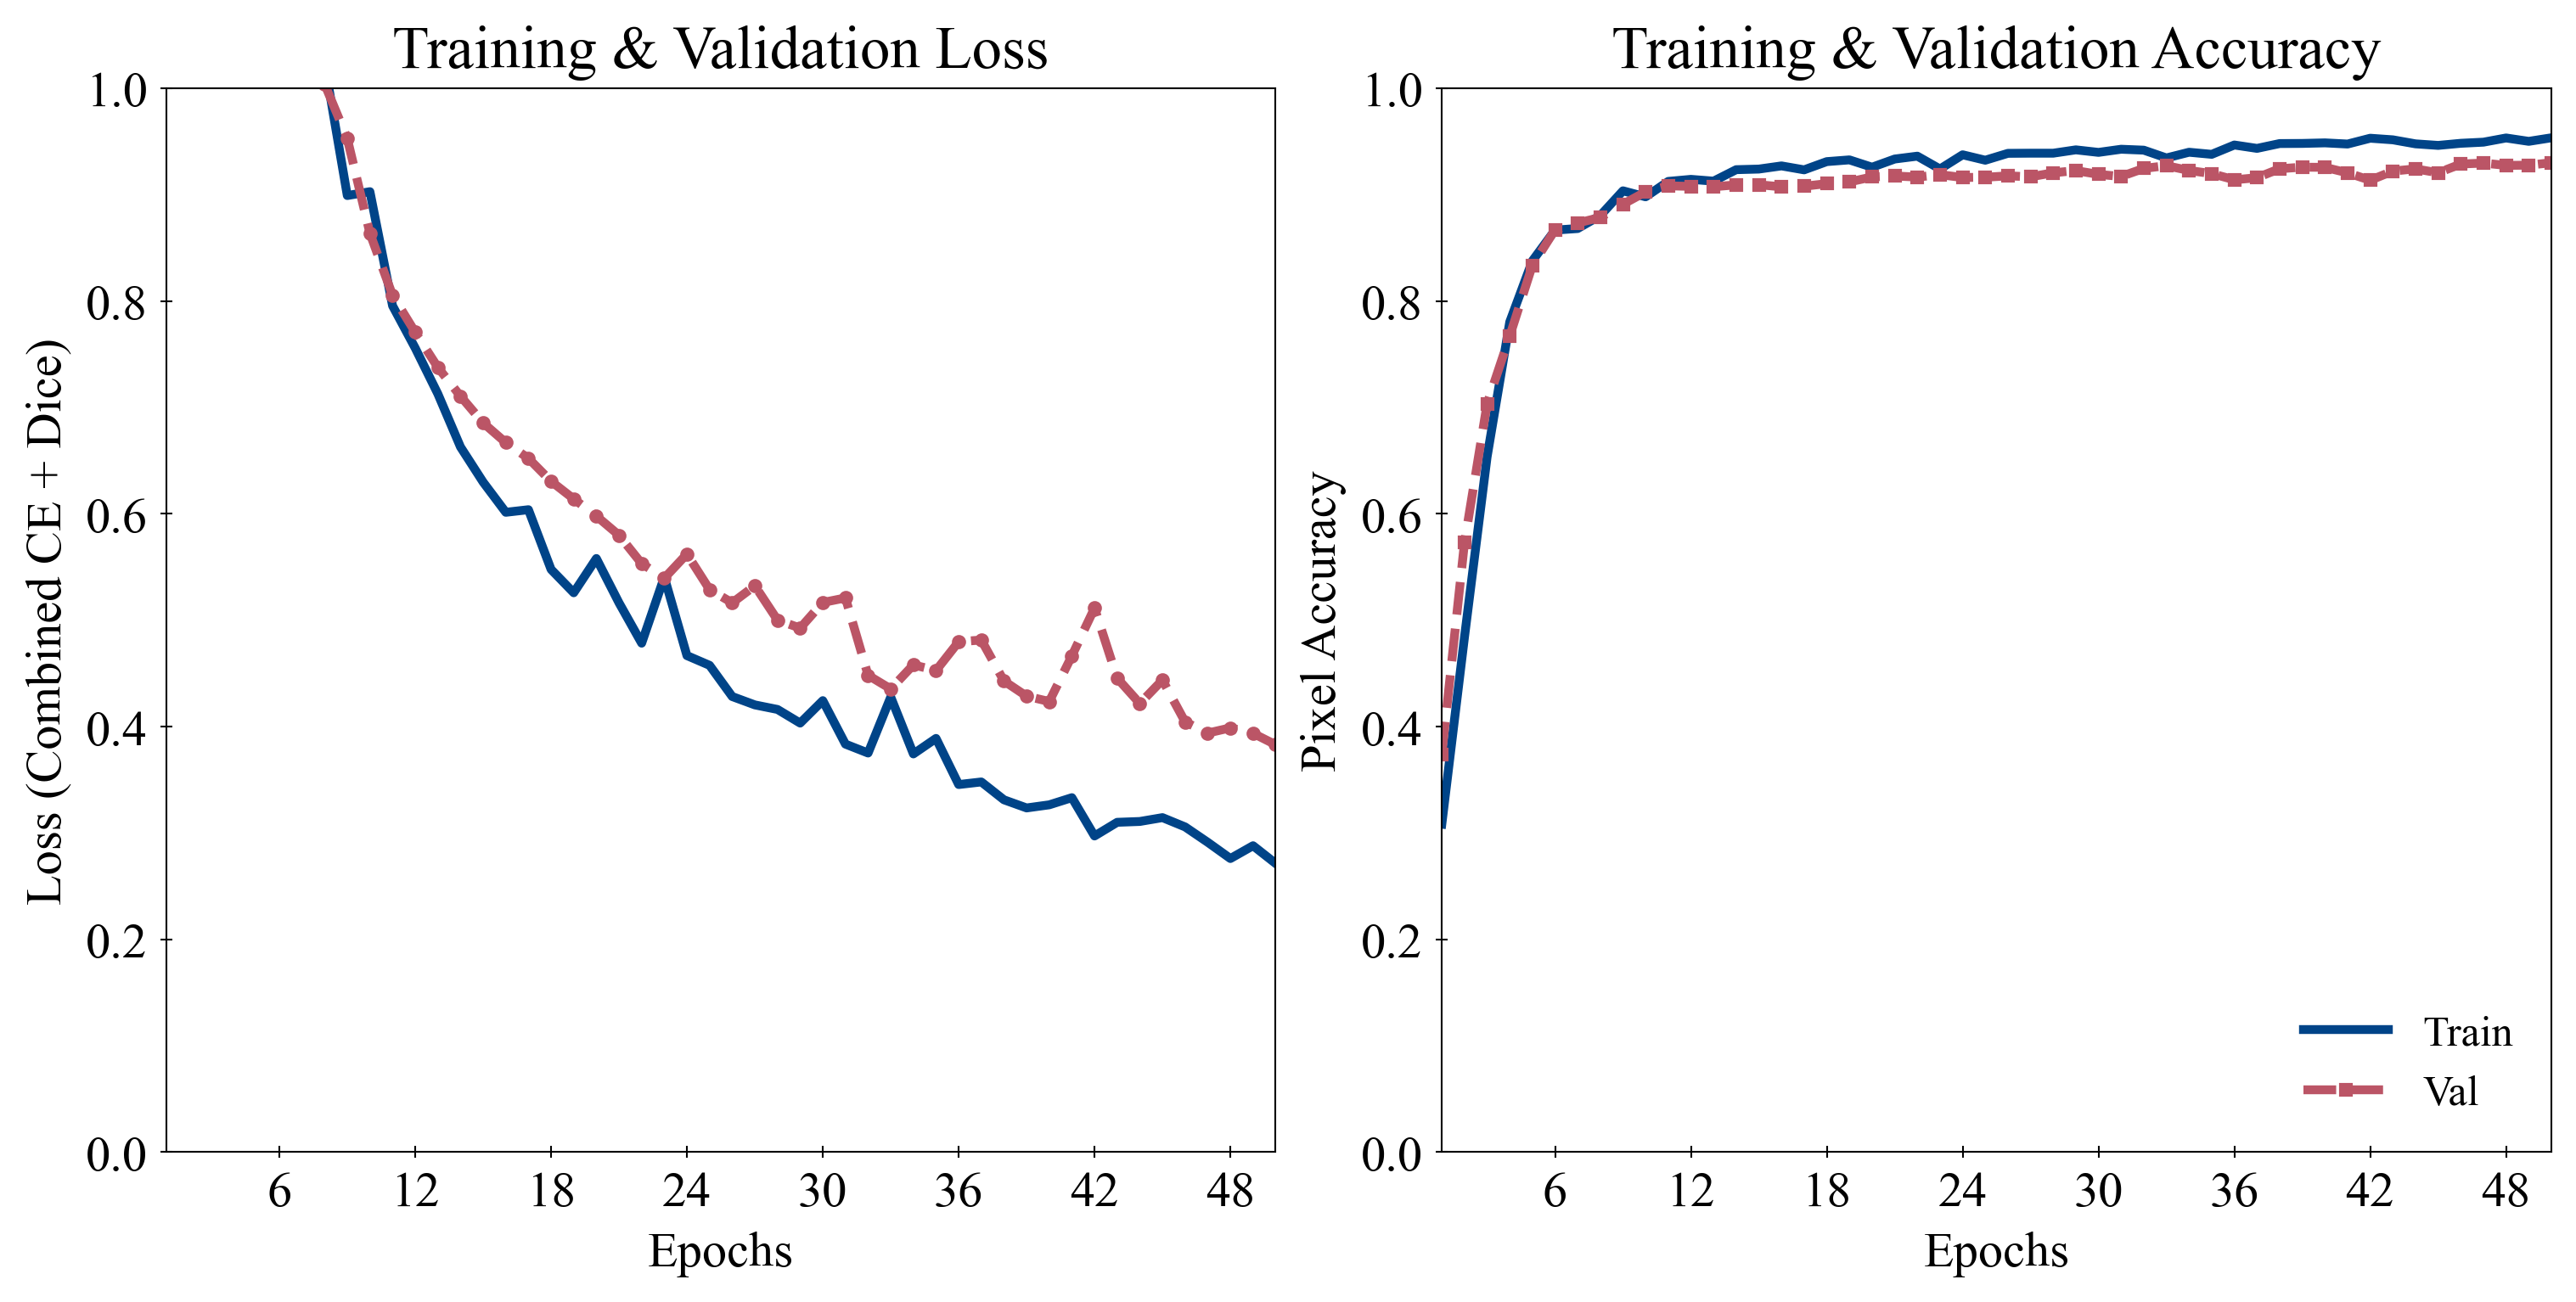

Saved:
..\..\models\comparison\unetpp_training_curves.png
..\..\models\comparison\unetpp_training_curves.pdf
U-Net++ best checkpoint (min val loss):
Epoch: 50
Train Acc: 95.35%
Val Acc: 93.00%
Val Loss: 0.3830


In [12]:
# Training curves for U-Net++ (proposed model) -- replaces the plain-U-Net Fig. in main.tex
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_publication_curves(history_df, out_dir, stem='unetpp_training_curves'):
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'], 'font.size': 14,
        'axes.labelsize': 14, 'axes.titlesize': 17, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 12, 'figure.dpi': 300, 'lines.linewidth': 2.5,
        'axes.grid': False, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    })
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    fig.patch.set_alpha(0.0)
    max_epoch = history_df['epoch'].max()
    for ax in [ax1, ax2]:
        ax.patch.set_alpha(0.0)
        ax.set_xlim(history_df['epoch'].min(), max_epoch)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(6))
        ax.set_ylim(0, 1)
        for side in ['bottom', 'left', 'top', 'right']:
            ax.spines[side].set_linewidth(0.5)
            ax.spines[side].set_color('black')
            ax.spines[side].set_visible(True)
        ax.tick_params(axis='x', colors='black', width=0.5, direction='inout')
        ax.tick_params(axis='y', colors='black', width=0.5, direction='inout')
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_color('black')
    ax1.plot(history_df['epoch'], history_df['train_loss'], color='#004488', linestyle='-', label='Train')
    ax1.plot(history_df['epoch'], history_df['val_loss'], color='#BB5566', linestyle='--', marker='o', markersize=3, label='Val')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (Combined CE + Dice)')
    ax1.set_title('Training & Validation Loss')
    ax2.plot(history_df['epoch'], history_df['train_acc'], color='#004488', linestyle='-', label='Train')
    ax2.plot(history_df['epoch'], history_df['val_acc'], color='#BB5566', linestyle='--', marker='s', markersize=3, label='Val')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Pixel Accuracy')
    ax2.set_title('Training & Validation Accuracy')
    ax2.legend(frameon=False, loc='lower right')
    plt.savefig(out_dir / (stem + '.png'), dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(out_dir / (stem + '.pdf'), format='pdf', bbox_inches='tight', transparent=True)
    plt.show()
    print('Saved:')
    print(out_dir / (stem + '.png'))
    print(out_dir / (stem + '.pdf'))

plot_publication_curves(unet_pp_history, Config.OUTPUT_DIR)

best_row = unet_pp_history.loc[unet_pp_history['val_loss'].idxmin()]
print('U-Net++ best checkpoint (min val loss):')
print('Epoch:', int(best_row['epoch']))
print('Train Acc: {:.2f}%'.format(best_row['train_acc'] * 100))
print('Val Acc: {:.2f}%'.format(best_row['val_acc'] * 100))
print('Val Loss: {:.4f}'.format(best_row['val_loss']))

## 8b. Candidate 3b -- U-Net++, ResNet34 encoder trained **from scratch** (no pretrained weights)

Same rationale as Candidate 2, applied to the nested-skip-connection architecture: isolates how much of
U-Net++'s performance comes from ImageNet transfer learning versus the decoder architecture itself.

In [13]:
unet_pp_scratch = smp.UnetPlusPlus(encoder_name=Config.ENCODER_NAME, encoder_weights=None,
                                    in_channels=3, classes=Config.NUM_CLASSES)
unet_pp_scratch, unet_pp_scratch_history = train_model(unet_pp_scratch, 'UNetPlusPlus_NoPretrained', train_loader, val_loader)
unet_pp_scratch_history.to_csv(Config.OUTPUT_DIR / 'UNetPlusPlus_NoPretrained_history.csv', index=False)

unet_pp_scratch_predict_fn = make_deep_predict_fn(unet_pp_scratch)
unet_pp_scratch_results = evaluate_model_on_split(unet_pp_scratch_predict_fn, data_split['test'], 'UNetPlusPlus_NoPretrained')
all_results.append(unet_pp_scratch_results)
unet_pp_scratch_results.describe()

[UNetPlusPlus_NoPretrained] Epoch 1/50:   0%|          | 0/7 [00:00<?, ?it/s]

[UNetPlusPlus_NoPretrained] Epoch 1/50:  14%|█▍        | 1/7 [00:00<00:02,  2.13it/s]

[UNetPlusPlus_NoPretrained] Epoch 1/50:  29%|██▊       | 2/7 [00:00<00:01,  2.75it/s]

[UNetPlusPlus_NoPretrained] Epoch 1/50:  43%|████▎     | 3/7 [00:01<00:01,  3.05it/s]

[UNetPlusPlus_NoPretrained] Epoch 1/50:  57%|█████▋    | 4/7 [00:01<00:00,  3.25it/s]

...

Evaluating UNetPlusPlus_NoPretrained:  83%|████████▎ | 10/12 [00:03<00:00,  2.94it/s]

Evaluating UNetPlusPlus_NoPretrained:  92%|█████████▏| 11/12 [00:03<00:00,  3.49it/s]

Evaluating UNetPlusPlus_NoPretrained: 100%|██████████| 12/12 [00:03<00:00,  3.95it/s]

Evaluating UNetPlusPlus_NoPretrained: 100%|██████████| 12/12 [00:03<00:00,  3.57it/s]

,pixel_accuracy,mean_tissue_dice,Background_dice,Background_iou,Background_precision,Background_recall,Background_f1,Background_specificity,Tissue_dice,Tissue_iou,...,OS_precision,OS_recall,OS_f1,OS_specificity,Vaginal_dice,Vaginal_iou,Vaginal_precision,Vaginal_recall,Vaginal_f1,Vaginal_specificity
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.834636,0.666893,0.885210,0.823128,0.864452,0.944451,0.885210,0.959442,0.833714,0.721163,...,0.765770,0.697436,0.716550,0.977579,0.450417,0.353623,0.566530,0.419780,0.450417,0.980106
std,0.093605,0.168271,0.163633,0.216416,0.229975,0.039507,0.163633,0.051179,0.075167,0.107040,...,0.120041,0.227556,0.177498,0.012386,0.346226,0.311259,0.390860,0.360646,0.346226,0.012153
min,0.689906,0.401040,0.509882,0.342175,0.358940,0.879896,0.509882,0.847240,0.698394,0.536564,...,0.523344,0.308462,0.424151,0.955324,0.000000,0.000000,0.000000,0.000000,0.000000,0.961027
25%,0.731424,0.542931,0.921665,0.855161,0.872191,0.925588,0.921665,0.937009,0.773217,0.630387,...,0.684282,0.591541,0.587125,0.973979,0.187146,0.106912,0.273920,0.138730,0.187146,0.973264
50%,0.881423,0.666959,0.956275,0.916255,0.975590,0.946403,0.956275,0.986001,0.868065,0.767212,...,0.807879,0.756177,0.776731,0.981377,0.421070,0.266872,0.799829,0.326452,0.421070,0.979485
75%,0.910186,0.810177,0.970245,0.942224,0.990410,0.976578,0.970245,0.994796,0.887212,0.797288,...,0.863695,0.868628,0.874482,0.985524,0.834267,0.715757,0.872567,0.795120,0.834267,0.987435
max,0.924022,0.885280,0.981536,0.963742,0.997888,0.994903,0.981536,0.997818,0.914228,0.842008,...,0.884235,0.962292,0.903210,0.993612,0.880886,0.787128,0.970577,0.892460,0.880886,0.998906


## 9. Candidate 4 -- DeepLabV3+ (pretrained ResNet34 encoder)

Atrous Spatial Pyramid Pooling captures multi-scale context, a strong general-purpose semantic segmentation architecture and a common SOTA reference point.

In [14]:
deeplab = smp.DeepLabV3Plus(encoder_name=Config.ENCODER_NAME, encoder_weights='imagenet',
                              in_channels=3, classes=Config.NUM_CLASSES)
deeplab, deeplab_history = train_model(deeplab, 'DeepLabV3Plus_Pretrained', train_loader, val_loader)

deeplab_predict_fn = make_deep_predict_fn(deeplab)
deeplab_results = evaluate_model_on_split(deeplab_predict_fn, data_split['test'], 'DeepLabV3Plus_Pretrained')
all_results.append(deeplab_results)
deeplab_results.describe()


[DeepLabV3Plus_Pretrained] Epoch 1/50:   0%|          | 0/7 [00:00<?, ?it/s]

[DeepLabV3Plus_Pretrained] Epoch 1/50:  14%|█▍        | 1/7 [00:00<00:02,  2.81it/s]

[DeepLabV3Plus_Pretrained] Epoch 1/50:  29%|██▊       | 2/7 [00:00<00:01,  3.85it/s]

[DeepLabV3Plus_Pretrained] Epoch 1/50:  43%|████▎     | 3/7 [00:00<00:00,  4.40it/s]

[DeepLabV3Plus_Pretrained] Epoch 1/50:  57%|█████▋    | 4/7 [00:00<00:00,  4.97it/s]

...

Evaluating DeepLabV3Plus_Pretrained:  83%|████████▎ | 10/12 [00:03<00:00,  2.90it/s]

Evaluating DeepLabV3Plus_Pretrained:  92%|█████████▏| 11/12 [00:03<00:00,  3.49it/s]

Evaluating DeepLabV3Plus_Pretrained: 100%|██████████| 12/12 [00:03<00:00,  4.05it/s]

Evaluating DeepLabV3Plus_Pretrained: 100%|██████████| 12/12 [00:03<00:00,  3.39it/s]

,pixel_accuracy,mean_tissue_dice,Background_dice,Background_iou,Background_precision,Background_recall,Background_f1,Background_specificity,Tissue_dice,Tissue_iou,...,OS_precision,OS_recall,OS_f1,OS_specificity,Vaginal_dice,Vaginal_iou,Vaginal_precision,Vaginal_recall,Vaginal_f1,Vaginal_specificity
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.904669,0.800161,0.947652,0.905403,0.946980,0.954157,0.947652,0.978285,0.895153,0.812748,...,0.840071,0.842933,0.834235,0.980864,0.671095,0.578285,0.638801,0.564850,0.587762,0.975334
std,0.044076,0.128739,0.058128,0.096632,0.062706,0.082829,0.058128,0.019949,0.043372,0.070706,...,0.095467,0.129281,0.091709,0.017571,0.338442,0.319276,0.390956,0.377377,0.371585,0.029475
min,0.833246,0.519032,0.810173,0.680917,0.763285,0.696414,0.810173,0.926492,0.834289,0.715692,...,0.662629,0.519864,0.661031,0.928716,0.000000,0.000000,0.000000,0.000000,0.000000,0.915629
25%,0.871681,0.732572,0.954813,0.913573,0.937639,0.966473,0.954813,0.969174,0.849233,0.737973,...,0.772761,0.840329,0.800350,0.981739,0.602323,0.432098,0.498056,0.283337,0.399375,0.970164
50%,0.922328,0.857213,0.971576,0.944727,0.964444,0.976803,0.971576,0.982301,0.899243,0.816946,...,0.880801,0.875910,0.876032,0.984506,0.830240,0.709811,0.849721,0.757572,0.765369,0.985840
75%,0.940233,0.895763,0.979415,0.959667,0.981700,0.991903,0.979415,0.991462,0.941451,0.889378,...,0.900346,0.932360,0.902020,0.988498,0.884150,0.792356,0.887345,0.875215,0.875202,0.996336
max,0.955909,0.921468,0.984568,0.969605,0.997428,0.996686,0.984568,0.997475,0.946306,0.898085,...,0.947381,0.960636,0.917464,0.995616,1.000000,1.000000,0.933841,0.906625,0.886129,1.000000


In [15]:
deeplab_history.to_csv(Config.OUTPUT_DIR / 'DeepLabV3Plus_Pretrained_history.csv', index=False)
print("Saved DeepLabV3Plus_Pretrained_history.csv")

Saved DeepLabV3Plus_Pretrained_history.csv


## 9b. Candidate 4b -- DeepLabV3+, ResNet34 encoder trained **from scratch** (no pretrained weights)

Same rationale as Candidate 2/3b, applied to the ASPP decoder: isolates how much of DeepLabV3+'s
performance comes from ImageNet transfer learning versus the architecture itself.

In [16]:
deeplab_scratch = smp.DeepLabV3Plus(encoder_name=Config.ENCODER_NAME, encoder_weights=None,
                                     in_channels=3, classes=Config.NUM_CLASSES)
deeplab_scratch, deeplab_scratch_history = train_model(deeplab_scratch, 'DeepLabV3Plus_NoPretrained', train_loader, val_loader)
deeplab_scratch_history.to_csv(Config.OUTPUT_DIR / 'DeepLabV3Plus_NoPretrained_history.csv', index=False)

deeplab_scratch_predict_fn = make_deep_predict_fn(deeplab_scratch)
deeplab_scratch_results = evaluate_model_on_split(deeplab_scratch_predict_fn, data_split['test'], 'DeepLabV3Plus_NoPretrained')
all_results.append(deeplab_scratch_results)
deeplab_scratch_results.describe()

[DeepLabV3Plus_NoPretrained] Epoch 1/50:   0%|          | 0/7 [00:00<?, ?it/s]

[DeepLabV3Plus_NoPretrained] Epoch 1/50:  14%|█▍        | 1/7 [00:00<00:02,  2.39it/s]

[DeepLabV3Plus_NoPretrained] Epoch 1/50:  29%|██▊       | 2/7 [00:00<00:01,  4.08it/s]

[DeepLabV3Plus_NoPretrained] Epoch 1/50:  43%|████▎     | 3/7 [00:00<00:00,  5.29it/s]

[DeepLabV3Plus_NoPretrained] Epoch 1/50:  57%|█████▋    | 4/7 [00:00<00:00,  6.17it/s]

...

Evaluating DeepLabV3Plus_NoPretrained:  83%|████████▎ | 10/12 [00:02<00:00,  3.15it/s]

Evaluating DeepLabV3Plus_NoPretrained:  92%|█████████▏| 11/12 [00:02<00:00,  3.76it/s]

Evaluating DeepLabV3Plus_NoPretrained: 100%|██████████| 12/12 [00:03<00:00,  4.31it/s]

Evaluating DeepLabV3Plus_NoPretrained: 100%|██████████| 12/12 [00:03<00:00,  3.83it/s]

,pixel_accuracy,mean_tissue_dice,Background_dice,Background_iou,Background_precision,Background_recall,Background_f1,Background_specificity,Tissue_dice,Tissue_iou,...,OS_precision,OS_recall,OS_f1,OS_specificity,Vaginal_dice,Vaginal_iou,Vaginal_precision,Vaginal_recall,Vaginal_f1,Vaginal_specificity
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.824616,0.661110,0.890708,0.828535,0.855331,0.966500,0.890708,0.939127,0.814560,0.693752,...,0.764663,0.691705,0.713637,0.975387,0.455132,0.346294,0.567597,0.430574,0.455132,0.968176
std,0.099390,0.160744,0.155784,0.199909,0.209406,0.025837,0.155784,0.077787,0.078130,0.109676,...,0.146347,0.214878,0.167623,0.016696,0.321869,0.274281,0.377232,0.337846,0.321869,0.022051
min,0.583084,0.363794,0.441756,0.283496,0.284473,0.921446,0.441756,0.724332,0.678419,0.513338,...,0.452869,0.330184,0.412962,0.942906,0.000000,0.000000,0.000000,0.000000,0.000000,0.930798
25%,0.766690,0.588864,0.902482,0.822299,0.835618,0.943730,0.902482,0.915183,0.759461,0.612204,...,0.699733,0.481678,0.580213,0.970785,0.263463,0.159799,0.217553,0.160911,0.263463,0.952240
50%,0.851229,0.654060,0.954961,0.913870,0.957654,0.971940,0.954961,0.974925,0.830012,0.710578,...,0.829850,0.733841,0.756333,0.980441,0.466681,0.304843,0.787665,0.450957,0.466681,0.964310
75%,0.891675,0.788306,0.967029,0.936163,0.972367,0.988683,0.967029,0.985916,0.869736,0.769499,...,0.873464,0.870392,0.860637,0.983743,0.717733,0.562348,0.800053,0.655201,0.717733,0.986925
max,0.940929,0.862546,0.982349,0.965311,0.992640,0.997731,0.982349,0.992412,0.931308,0.871446,...,0.906787,0.923375,0.881518,0.997562,0.840329,0.724628,0.968596,0.897744,0.840329,0.999968


## 11. Aggregate Comparison Table & Figure

In [17]:
combined = pd.concat(all_results, ignore_index=True)
combined.to_csv(Config.RESULTS_DIR / 'per_sample_results_all_models.csv', index=False)

summary_rows = []
for model_name, group in combined.groupby('model'):
    row = {'Model': model_name,
           'Pixel Accuracy': f"{group['pixel_accuracy'].mean():.4f} +/- {group['pixel_accuracy'].std():.4f}",
           'Mean Tissue DSC': f"{group['mean_tissue_dice'].mean():.4f} +/- {group['mean_tissue_dice'].std():.4f}"}
    for cname in Config.CLASS_NAMES:
        row[f'{cname} Dice'] = f"{group[f'{cname}_dice'].mean():.4f} +/- {group[f'{cname}_dice'].std():.4f}"
        row[f'{cname} IoU'] = f"{group[f'{cname}_iou'].mean():.4f} +/- {group[f'{cname}_iou'].std():.4f}"
    summary_rows.append(row)

model_order = ['UNet_Pretrained_Published', 'UNet_NoPretrained',
               'UNetPlusPlus_Pretrained', 'UNetPlusPlus_NoPretrained',
               'DeepLabV3Plus_Pretrained', 'DeepLabV3Plus_NoPretrained']
summary_df = pd.DataFrame(summary_rows).set_index('Model').reindex(model_order).reset_index()
summary_df.to_csv(Config.RESULTS_DIR / 'comparison_summary_table.csv', index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
summary_df


,Model,Pixel Accuracy,Mean Tissue DSC,Background Dice,Background IoU,Tissue Dice,Tissue IoU,OS Dice,OS IoU,Vaginal Dice,Vaginal IoU
0,UNet_Pretrained_Published,0.9022 +/- 0.0431,0.8110 +/- 0.1345,0.9364 +/- 0.0801,0.8890 +/- 0.1247,0.8896 +/- 0.0391,0.8033 +/- 0.0632,0.8379 +/- 0.0934,0.7301 +/- 0.1245,0.7056 +/- 0.3443,0.6227 +/- 0.3221
1,UNet_NoPretrained,0.8218 +/- 0.0783,0.6288 +/- 0.1690,0.8937 +/- 0.0997,0.8199 +/- 0.1468,0.8273 +/- 0.0698,0.7106 +/- 0.0947,0.6834 +/- 0.1883,0.5471 +/- 0.2145,0.3757 +/- 0.3194,0.2791 +/- 0.2676
2,UNetPlusPlus_Pretrained,0.9086 +/- 0.0439,0.8096 +/- 0.1461,0.9490 +/- 0.0510,0.9068 +/- 0.0865,0.9039 +/- 0.0329,0.8261 +/- 0.0540,0.8442 +/- 0.1315,0.7471 +/- 0.1607,0.6807 +/- 0.3449,0.5935 +/- 0.3285
3,UNetPlusPlus_NoPretrained,0.8346 +/- 0.0936,0.6669 +/- 0.1683,0.8852 +/- 0.1636,0.8231 +/- 0.2164,0.8337 +/- 0.0752,0.7212 +/- 0.1070,0.7165 +/- 0.1775,0.5844 +/- 0.2069,0.4504 +/- 0.3462,0.3536 +/- 0.3113
4,DeepLabV3Plus_Pretrained,0.9047 +/- 0.0441,0.8002 +/- 0.1287,0.9477 +/- 0.0581,0.9054 +/- 0.0966,0.8952 +/- 0.0434,0.8127 +/- 0.0707,0.8342 +/- 0.0917,0.7248 +/- 0.1269,0.6711 +/- 0.3384,0.5783 +/- 0.3193
5,DeepLabV3Plus_NoPretrained,0.8246 +/- 0.0994,0.6611 +/- 0.1607,0.8907 +/- 0.1558,0.8285 +/- 0.1999,0.8146 +/- 0.0781,0.6938 +/- 0.1097,0.7136 +/- 0.1676,0.5779 +/- 0.1941,0.4551 +/- 0.3219,0.3463 +/- 0.2743


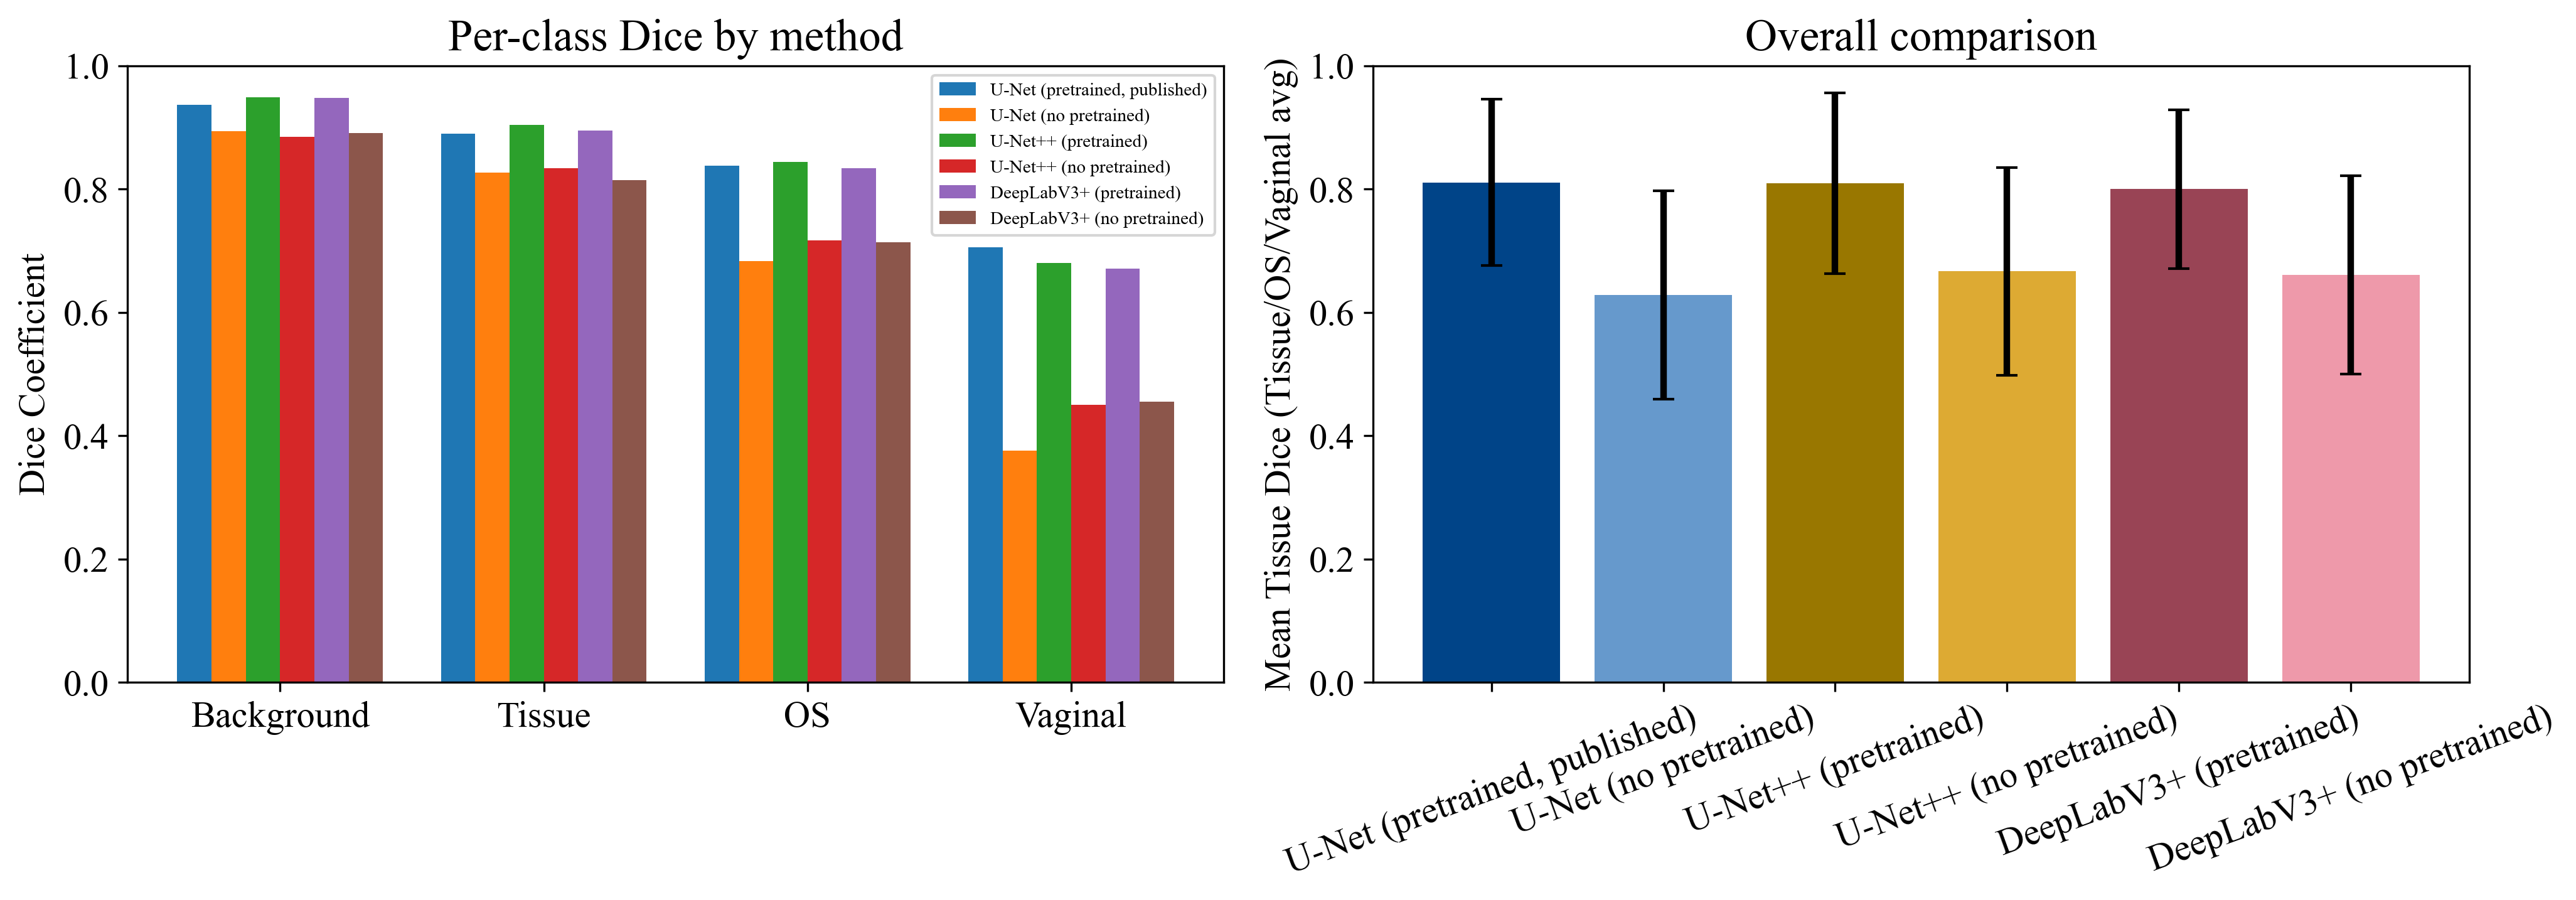

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_labels = {
    'UNet_Pretrained_Published': 'U-Net (pretrained, published)',
    'UNet_NoPretrained': 'U-Net (no pretrained)',
    'UNetPlusPlus_Pretrained': 'U-Net++ (pretrained)',
    'UNetPlusPlus_NoPretrained': 'U-Net++ (no pretrained)',
    'DeepLabV3Plus_Pretrained': 'DeepLabV3+ (pretrained)',
    'DeepLabV3Plus_NoPretrained': 'DeepLabV3+ (no pretrained)',
}

x = np.arange(len(Config.CLASS_NAMES))
width = 0.13
for i, model_name in enumerate(model_order):
    group = combined[combined['model'] == model_name]
    means = [group[f'{c}_dice'].mean() for c in Config.CLASS_NAMES]
    axes[0].bar(x + i * width, means, width, label=model_labels.get(model_name, model_name))
axes[0].set_xticks(x + width * (len(model_order) - 1) / 2)
axes[0].set_xticklabels(Config.CLASS_NAMES)
axes[0].set_ylabel('Dice Coefficient')
axes[0].set_title('Per-class Dice by method')
axes[0].legend(fontsize=7)
axes[0].set_ylim(0, 1)

means_overall = [combined[combined['model'] == m]['mean_tissue_dice'].mean() for m in model_order]
stds_overall = [combined[combined['model'] == m]['mean_tissue_dice'].std() for m in model_order]
axes[1].bar([model_labels.get(m, m) for m in model_order], means_overall, yerr=stds_overall, capsize=4,
            color=['#004488', '#6699CC', '#997700', '#DDAA33', '#994455', '#EE99AA'])
axes[1].set_ylabel('Mean Tissue Dice (Tissue/OS/Vaginal avg)')
axes[1].set_title('Overall comparison')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.savefig(Config.RESULTS_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Notes for the rebuttal

- All methods were evaluated on the **identical held-out test split** used for the published model's reported numbers
  (`models/data_split.json`), so `results/analysis_results/table1_overall_performance.csv` and
  `results/model_comparison/comparison_summary_table.csv` are directly comparable.
- `UNet_NoPretrained` isolates the contribution of ImageNet transfer learning: a large gap versus the published model
  indicates pretraining is doing real work on this small (51-image) training set.
- `UNetPlusPlus_Pretrained` and `DeepLabV3Plus_Pretrained` represent standard, actively-maintained SOTA segmentation
  architectures (via `segmentation_models_pytorch`), included so the published architecture's performance can be
  contextualised against alternatives commonly used in small-sample biomedical image segmentation. Each also has a
  no-pretrained-encoder variant (`*_NoPretrained`) to isolate the transfer-learning contribution.
- If `NUM_EPOCHS` was reduced for a quick smoke test, re-run cells 7 (Candidate 2), 9 (Candidate 3), and 11
  (Candidate 4) with `Config.NUM_EPOCHS = 50` (or your preferred full budget) before using these numbers in the paper.
